# 07 · Transition integration, the pooled channel on the learn rate

Runs the transition grid, joint-trained BKT whose learn rate is suppressed by the pooled misconception state, the emission left plain, so any delta against the engine baseline is the transition's alone. The learn rate after turn t is learn_k times one minus gamma times m_t, one global gamma, an absolute suppression fraction per unit of chain state, descriptive. The chains are fitted once under the chain of record and shared frozen, the m entering each turn is the pooled state before it, solution row consumed by the chains, never by BKT, and evaluation is paper-aligned throughout.

**The rows.** Validity, gamma pinned to 0, is the engine's own BKT, it reproduces the emission-stage validity row exactly, same engine, same seed, verified cross-script, and sits within the known three-tenths band of the frozen M1, the residual being optimizer and initialization against pyBKT, not protocol. Then every pooling method, max, noisy_or, top2_or, mean, each under gamma free and gamma pinned to 1, full suppression, a live belief at m near 1 blocking that turn's learning entirely.

**Reading order.** Validity first, then the free gammas, then the deltas in section 4, then the trajectory diagnostic in section 5, which checks the one prediction this door makes that no emission model could, dialogues whose beliefs die early should show steeper late-dialogue mastery growth than dialogues whose beliefs persist. Single-seed deltas at this effect size wobble by a few thousandths, treat every delta as descriptive.

## 1. Setup

Chains fitted once, shared by every row.

In [1]:
import pandas as pd
from scripts.load_data import load_paper_filtered_data
from scripts.chain import TriggerChain
from scripts.misconception_chains import MisconceptionChains
from scripts.emission_integration_pooled import CHAIN_OF_RECORD
from scripts.transition_integration_pooled import TransitionIntegrationPooled

train_df = load_paper_filtered_data("data/mathdial_train.csv")
test_df = load_paper_filtered_data("data/mathdial_test.csv")

chains = MisconceptionChains(train_df, test_df, chain_class=TriggerChain,
                             chain_kwargs=dict(CHAIN_OF_RECORD))
chains.run()
chains.summary()

,chain,pi,onset,resolve,pP_i,pP_a,expected_dwell_turns,accuracy,tpr,tnr,auc,f1,informative_cells
0,comprehension,0.05,0.0,0.0323,0.02,0.97,31.0,0.6327,0.6705,0.3704,0.5639,0.7614,1285
1,relevance,0.05,0.0,0.0535,0.02,0.97,18.7,0.6370,0.6061,0.7222,0.6749,0.7101,135
2,principles,0.05,0.0,0.0113,0.02,0.97,88.8,0.8784,0.7742,0.9535,0.8593,0.8421,74
3,wrong_operation,0.05,0.0,0.0881,0.02,0.97,11.3,0.7036,0.5512,0.8435,0.7511,0.6403,1164
4,steps,0.05,0.0,0.0475,0.02,0.97,21.0,0.8516,0.5580,0.9599,0.7217,0.6696,512


## 2. Rows

Nine fits, loop-built so each row's configuration is its name.

`second_max` is deliberately excluded from the grid. It is a stratification diagnostic, not a combination rule, as a pooled risk it would assert that the strongest live belief contributes nothing and only the second-strongest matters, a semantics no reading of the channel supports. It stays in the registry for the co-elevation analysis, where the second-strongest state is exactly the right variable.

In [2]:
POOLINGS = ["max", "noisy_or", "top2_or", "mean"]

ROWS = {"validity, gamma=0": {"pooling": "max", "pin_gamma": 0.0}}
for pooling in POOLINGS:
    ROWS[f"{pooling}, free"] = {"pooling": pooling}
    ROWS[f"{pooling}, gamma=1"] = {"pooling": pooling, "pin_gamma": 1.0}

models = {}
for name, kwargs in ROWS.items():
    model = TransitionIntegrationPooled(train_df, test_df, chains=chains,
                                        **kwargs)
    model.run()
    models[name] = model
    print(f"{name:22s} {model.metrics}")

validity, gamma=0      {'accuracy': 0.6035, 'auc': 0.6397, 'f1': 0.5531, 'turns': 1985, 'gamma': 0.0, 'pooling': 'max'}
max, free              {'accuracy': 0.6015, 'auc': 0.6389, 'f1': 0.5493, 'turns': 1985, 'gamma': 0.03, 'pooling': 'max'}
max, gamma=1           {'accuracy': 0.6091, 'auc': 0.6436, 'f1': 0.5566, 'turns': 1985, 'gamma': 1.0, 'pooling': 'max'}
noisy_or, free         {'accuracy': 0.6015, 'auc': 0.6392, 'f1': 0.5493, 'turns': 1985, 'gamma': 0.0123, 'pooling': 'noisy_or'}
noisy_or, gamma=1      {'accuracy': 0.605, 'auc': 0.643, 'f1': 0.551, 'turns': 1985, 'gamma': 1.0, 'pooling': 'noisy_or'}
top2_or, free          {'accuracy': 0.6015, 'auc': 0.6391, 'f1': 0.5493, 'turns': 1985, 'gamma': 0.0179, 'pooling': 'top2_or'}
top2_or, gamma=1       {'accuracy': 0.6065, 'auc': 0.6436, 'f1': 0.5535, 'turns': 1985, 'gamma': 1.0, 'pooling': 'top2_or'}
mean, free             {'accuracy': 0.602, 'auc': 0.6392, 'f1': 0.5506, 'turns': 1985, 'gamma': 0.0001, 'pooling': 'mean'}
mean, gamma=1  

## 3. Results table

The frozen M1 trio is the anchor, deltas against it are context, section 4 carries the inference.

In [3]:
M1 = {"accuracy": 0.6065, "auc": 0.6428, "f1": 0.5560}

results = pd.DataFrame(
    [{"row": name, **models[name].metrics} for name in ROWS])
for metric in ("accuracy", "auc", "f1"):
    results[f"d_{metric}"] = (results[metric] - M1[metric]).round(4)
results = results.set_index("row")
results[["pooling", "gamma", "accuracy", "d_accuracy",
         "auc", "d_auc", "f1", "d_f1", "turns"]]

,pooling,gamma,accuracy,d_accuracy,auc,d_auc,f1,d_f1,turns
row,,,,,,,,,
"validity, gamma=0",max,0.0000,0.6035,-0.0030,0.6397,-0.0031,0.5531,-0.0029,1985
"max, free",max,0.0300,0.6015,-0.0050,0.6389,-0.0039,0.5493,-0.0067,1985
"max, gamma=1",max,1.0000,0.6091,0.0026,0.6436,0.0008,0.5566,0.0006,1985
"noisy_or, free",noisy_or,0.0123,0.6015,-0.0050,0.6392,-0.0036,0.5493,-0.0067,1985
"noisy_or, gamma=1",noisy_or,1.0000,0.6050,-0.0015,0.6430,0.0002,0.5510,-0.0050,1985
"top2_or, free",top2_or,0.0179,0.6015,-0.0050,0.6391,-0.0037,0.5493,-0.0067,1985
"top2_or, gamma=1",top2_or,1.0000,0.6065,0.0000,0.6436,0.0008,0.5535,-0.0025,1985
"mean, free",mean,0.0001,0.6020,-0.0045,0.6392,-0.0036,0.5506,-0.0054,1985
"mean, gamma=1",mean,1.0000,0.6040,-0.0025,0.6396,-0.0032,0.5514,-0.0046,1985


## 4. Deltas against the engine baseline

Every model against the validity row's own three metrics, code path, protocol, optimizer, and per-KC initialization held fixed, so each delta isolates what the transition coupling changed. Sorted by AUC delta.

In [4]:
baseline = models["validity, gamma=0"].metrics
deltas = pd.DataFrame([
    {"row": name,
     "d_accuracy": round(models[name].metrics["accuracy"]
                         - baseline["accuracy"], 4),
     "d_auc": round(models[name].metrics["auc"] - baseline["auc"], 4),
     "d_f1": round(models[name].metrics["f1"] - baseline["f1"], 4)}
    for name in ROWS if name != "validity, gamma=0"])
deltas = deltas.set_index("row").sort_values("d_auc", ascending=False)
deltas

,d_accuracy,d_auc,d_f1
row,,,
"max, gamma=1",0.0056,0.0039,0.0035
"top2_or, gamma=1",0.0030,0.0039,0.0004
"noisy_or, gamma=1",0.0015,0.0033,-0.0021
"mean, gamma=1",0.0005,-0.0001,-0.0017
"noisy_or, free",-0.0020,-0.0005,-0.0038
"mean, free",-0.0015,-0.0005,-0.0025
"top2_or, free",-0.0020,-0.0006,-0.0038
"max, free",-0.0020,-0.0008,-0.0038


## 5. Trajectory diagnostic

The door's own prediction, made by no emission model. Test dialogues whose pooled state started live and died by mid-dialogue against dialogues where it persisted, mean filtered mastery before each turn, under the validity model and the best **free-gamma** row, the fitted model, not a pinned extreme. Three caveats govern the reading. The groups are heavily unbalanced, around a dozen early-death dialogues against hundreds persisting, and the early-death group is unusually correct, so most visual divergence is composition and correctness history, not transition mechanics. The early-death group shrinks across turns, late-curve bends can reflect the changing population rather than within-dialogue growth, per-turn counts are printed, read nothing past where they thin. And with the fitted gamma near zero the two panels should nearly coincide, which is the expected picture of the null, not a rendering error.

dialogue counts: {'persisted': np.int64(295), 'died early': np.int64(12)}
died early: per-turn dialogue counts {1: np.int64(12), 2: np.int64(12), 3: np.int64(12), 4: np.int64(12), 5: np.int64(8), 6: np.int64(3), 7: np.int64(3), 8: np.int64(2)}
persisted: per-turn dialogue counts {1: np.int64(295), 2: np.int64(295), 3: np.int64(295), 4: np.int64(295), 5: np.int64(220), 6: np.int64(153), 7: np.int64(112), 8: np.int64(74)}


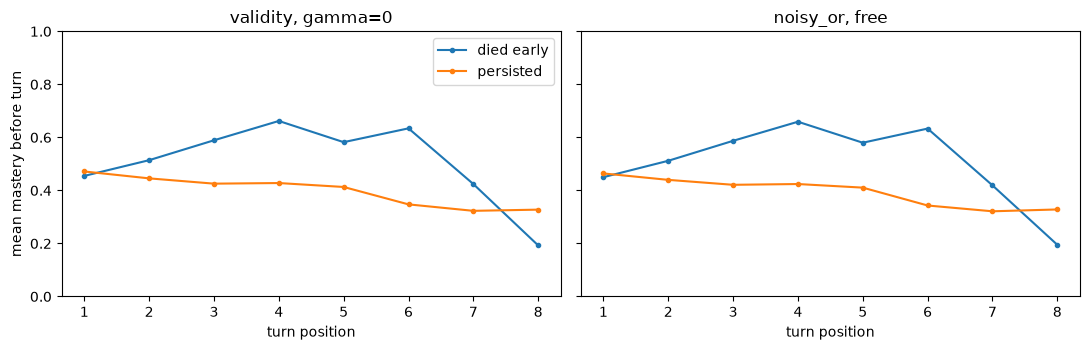

In [5]:
import numpy as np
import matplotlib.pyplot as plt

free_rows = [r for r in deltas.index if r.endswith(", free")]
best_free = deltas.loc[free_rows, "d_auc"].idxmax()
compare = {"validity, gamma=0": models["validity, gamma=0"],
           best_free: models[best_free]}

from scripts.pooling import Pooling
groups = {}
for d, track in chains.predict_states(test_df).items():
    m = Pooling.max(track)
    if len(m) < 5 or m[1] < 0.5:
        continue  # never live, out of scope
    mid = len(m) // 2
    groups[d] = "died early" if m[mid:].max() < 0.5 else "persisted"
counts = pd.Series(groups).value_counts()
print("dialogue counts:", dict(counts))

def mastery_curves(model):
    rows = []
    for d, per_kc in model.test.items():
        if d not in groups:
            continue
        per_pos = {}
        for kc, seq in per_kc.items():
            p = model.parameters.get(kc)
            if p is None:
                continue
            pm, pu = 1 - p["slip"], p["guess"]
            state = p["prior"]
            for c, m, pos in seq:
                per_pos.setdefault(pos, []).append(state)
                observed = pm if c else 1 - pm
                other = pu if c else 1 - pu
                posterior = state * observed / max(
                    state * observed + (1 - state) * other, 1e-12)
                state = posterior + (1 - posterior) * model._learn_at(p, m)
        for pos, states in per_pos.items():
            rows.append({"group": groups[d], "position": pos,
                         "mastery": float(np.mean(states)),
                         "dialogue": d})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (name, model) in zip(axes, compare.items()):
    curves = mastery_curves(model)
    for group, sub in curves.groupby("group"):
        line = sub.groupby("position").agg(mastery=("mastery", "mean"),
                                           n=("dialogue", "nunique"))
        line = line[line.index <= 8]
        ax.plot(line.index, line["mastery"], marker="o", markersize=3,
                label=group)
        if name == list(compare)[0]:
            print(f"{group}: per-turn dialogue counts",
                  dict(line["n"].astype(int)))
    ax.set_title(name)
    ax.set_xlabel("turn position")
    ax.set_ylim(0, 1)
axes[0].set_ylabel("mean mastery before turn")
axes[0].legend()
plt.tight_layout()
plt.show()

## 6. Interpretation ledger

- The validity row must match the emission notebooks' validity row on all three metrics, same engine, same seed, and sit within the known band of frozen M1, if it does not, stop and diagnose before reading anything else.
- The fitted gamma is a relative suppression of the learn rate per unit of chain state, descriptive, clipping and competition with learn_k make any causal impasse-rate reading unsafe, and learn and gamma are coupled through the same expected counts, so read them together, a high gamma beside an inflated learn is reparameterization, not suppression.
- The emission stage's caveats carry over whole, selection on the test set makes deltas descriptive, and single-seed deltas wobble by a few thousandths at this effect size.
- The trajectory diagnostic is the door's distinctive readout, a late-turn upward bend for the early-death group that the validity model lacks is the impasse signature, its absence with a near-zero gamma closes the persistence door too, itself the map-completing finding.
- The redundancy fact from the emission post-mortem applies here in weakened form, correctness history sets mastery levels, gamma reshapes when mastery rises, the trajectory-shape information is what correctness history does not contain.

## 7. Why the transition channel did not improve prediction

The free fits are the verdict, every fitted gamma sits at or near zero, 0.03 down to the 0.0001 bound across the poolings, and review diagnostics showed the default fit's 0.03 is itself an inferior local solution, a near-zero start reaches a better training likelihood with gamma at its lower bound, so the maximum-likelihood answer is gamma effectively zero. The mechanisms, in order of force.

**Persistence makes the multiplier absorbable.** With 73 per cent of the state's variance between dialogues, a mean test value near 0.77, and lag-one correlation 0.75, the suppression term is close to a constant within any KC's sequence, and a constant multiplier on learn is indistinguishable from a smaller learn, effective learn approximately learn times one minus gamma times the mean state. The data cannot separate a genuine time-varying suppression from a different baseline learning rate, and EM proves it by compensation, forcing gamma to 1 raises the mean fitted learn from 0.35 to 0.50, partially undoing the imposed suppression.

**The pinned gain is not supported by the model's own objective.** Gamma pinned to 1 costs 37 nats of training likelihood against gamma zero while nudging test AUC by 0.0039, an interval spanning zero under a paired dialogue bootstrap, and the free optimizer, shown the full range, declines that configuration. A ranking nudge the generative objective rejects reads as noise or accidental regularization, not effect.

**Timing does not rescue it.** The defensible alternative, conditioning the transition on the post-turn state so the current turn's annotation informs the next learning opportunity, was tested in review, the fitted gamma rises to 0.21 but AUC does not move, so the null is not an artifact of the pre-turn convention.

**The connection is coarse and the identification chain is long.** One global scalar suppresses learning for every KC on the turn, a procedural belief gating conceptual KCs and vice versa, and a transition effect must survive the chain from state through altered latent learning to a later occurrence of the same KC to changed correctness, harder to estimate than any immediate emission relationship even with 87 per cent of scored turns containing a repeated KC.

**The trajectory diagnostic is composition, not mechanism.** The early-death group is around a dozen dialogues, unusually correct, 75 per cent against 42, shrinking to two or three dialogues by the late turns, so the baseline model already separates the groups' curves through correctness history alone, and nothing in the figure attributes divergence to the transition.

**Conclusion.** Pooled misconception persistence provides no detectable information about subsequent learning beyond ordinary correctness history. The grouped transition variant and the stacked transition-plus-emission row are not built, the evidence here does not earn them.

## 8. Notes

- Every model keeps its fitted parameters at `.parameters` and the shared frozen chains at `.chains`, nothing here refits the chains.
- The grouped transition variant and the stacking row are closed on this grid's evidence, see section 7.
- The winner's row name, pooling, and gamma get logged with the pick.